PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
Using device: cuda

=== load_cifar10 called ===
batch_size=64, train=False, num_workers=2, normalize=False

=== get_cifar10_transform called ===
normalize=False
Added ToTensor() to transform pipeline.
Skipping normalization.
Final transform: Compose(
    ToTensor()
)


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Dataset loaded.
Dataset length: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
DataLoader created.
Sample batch shape: torch.Size([64, 3, 32, 32])
Sample labels shape: torch.Size([64])

=== show_images called ===
num_images=8, normalized=True

=== unnormalize_images called ===
Input tensor shape: torch.Size([8, 3, 32, 32])
Unnormalized tensor shape: torch.Size([8, 3, 32, 32])


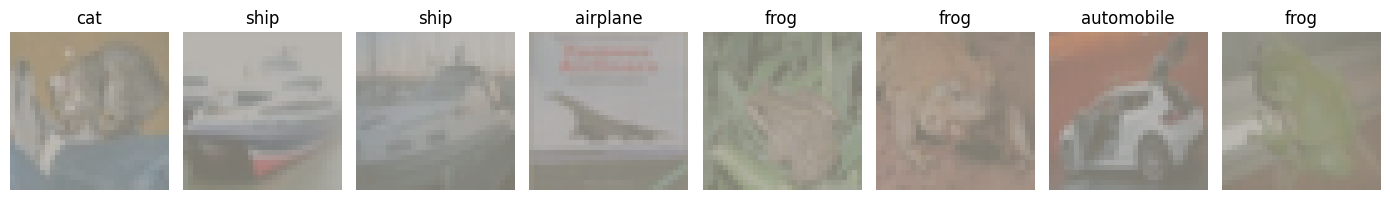

Displayed images successfully.


In [1]:
# Data Loading and Visualization

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Normalize Input

# Hardcoded to avoid recomputing (known values)
# https://docs.pytorch.org/tutorials/beginner/introyt/introyt1_tutorial.html
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


def get_cifar10_transform(normalize=True):
    print("\n=== get_cifar10_transform called ===")
    print(f"normalize={normalize}")

    transform_list = [transforms.ToTensor()]
    print("Added ToTensor() to transform pipeline.")

    if normalize:
        transform_list.append(transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD))
        print(f"Added Normalize with mean={CIFAR10_MEAN} and std={CIFAR10_STD}")
    else:
        print("Skipping normalization.")

    transform = transforms.Compose(transform_list)
    print("Final transform:", transform)
    return transform

# Unnormalization for image display
def unnormalize_images(images, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    print("\n=== unnormalize_images called ===")
    print("Input tensor shape:", images.shape)

    mean_tensor = torch.tensor(mean, device=images.device).view(1, 3, 1, 1)
    std_tensor = torch.tensor(std, device=images.device).view(1, 3, 1, 1)

    unnormalized = images * std_tensor + mean_tensor
    unnormalized = torch.clamp(unnormalized, 0.0, 1.0)

    print("Unnormalized tensor shape:", unnormalized.shape)
    return unnormalized

def show_images(images, labels, classes, num_images=8, normalized=True):
    print("\n=== show_images called ===")
    print(f"num_images={num_images}, normalized={normalized}")

    images_to_show = images[:num_images].detach().cpu()

    if normalized:
        images_to_show = unnormalize_images(images_to_show)

    plt.figure(figsize=(14, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = images_to_show[i].permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(classes[labels[i].item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    print("Displayed images successfully.")


# Load CIFAR-10 dataset=
def load_cifar10(batch_size=64, train=False, num_workers=2, normalize=True):
    print("\n=== load_cifar10 called ===")
    print(f"batch_size={batch_size}, train={train}, num_workers={num_workers}, normalize={normalize}")

    transform = get_cifar10_transform(normalize=normalize)

    dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=train,
        download=True,
        transform=transform
    )
    print("Dataset loaded.")
    print("Dataset length:", len(dataset))
    print("Classes:", dataset.classes)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=num_workers
    )
    print("DataLoader created.")

    images, labels = next(iter(loader))
    print("Sample batch shape:", images.shape)
    print("Sample labels shape:", labels.shape)

    return dataset, loader

test_dataset, test_loader = load_cifar10(batch_size=64, train=False, num_workers=2,normalize=False)

images, labels = next(iter(test_loader))
show_images(images, labels, test_dataset.classes, num_images=8)


=== load_cifar10 called ===
batch_size=64, train=False, num_workers=2, normalize=True

=== get_cifar10_transform called ===
normalize=True
Added ToTensor() to transform pipeline.
Added Normalize with mean=(0.4914, 0.4822, 0.4465) and std=(0.247, 0.2435, 0.2616)
Final transform: Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
Dataset loaded.
Dataset length: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
DataLoader created.
Sample batch shape: torch.Size([64, 3, 32, 32])
Sample labels shape: torch.Size([64])

=== show_images called ===
num_images=8, normalized=True

=== unnormalize_images called ===
Input tensor shape: torch.Size([8, 3, 32, 32])
Unnormalized tensor shape: torch.Size([8, 3, 32, 32])


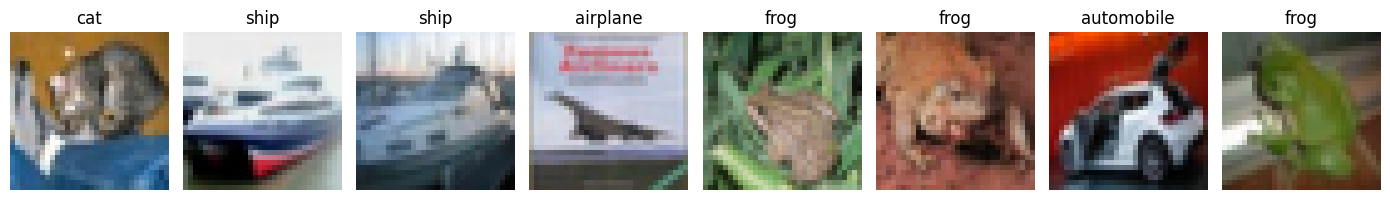

Displayed images successfully.


In [ ]:
# Reload test set

test_dataset, test_loader = load_cifar10(
    batch_size=64,
    train=False,
    num_workers=2,
    normalize=True
)

images, labels = next(iter(test_loader))
show_images(images, labels, test_dataset.classes, num_images=8, normalized=True)

In [ ]:
# Model eval (Accuracy)
# Optional as a sanity check.

def evaluate_model_accuracy(model, loader, device, max_batches=None):
    print("\n=== evaluate_model_accuracy called ===")
    model.eval()

    total = 0
    correct = 0

    # Discard unneeded gradient tracking info
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                print(f"Reached max_batches={max_batches}. Stopping early.")
                break

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            batch_correct = (preds == labels).sum().item()
            batch_total = labels.size(0)

            correct += batch_correct
            total += batch_total

            if batch_idx % 20 == 0:
                print(f"Batch {batch_idx}: batch_correct={batch_correct}, running_accuracy={correct/total:.4f}")

    accuracy = correct / total if total > 0 else 0.0
    print(f"Final accuracy: {accuracy:.4f}")
    return accuracy

# Find the dataset poistions of images the model already classifies correctly
# Typically, UAP should operate on those images otherwise its not useful
# to work on images already misclassified.
def collect_correct_indices(model, loader, device, max_correct=None):
    print("\n=== collect_correct_indices called ===")
    print(f"max_correct={max_correct}")
    print("! This assumes loader.shuffle = False")

    model.eval()
    correct_indices = []
    dataset_index = 0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            # For each image row
            # Find class index with largest score
            preds = outputs.argmax(dim=1)

            batch_matches = (preds == labels).cpu()

            for i in range(len(batch_matches)):
                if batch_matches[i].item():
                    correct_indices.append(dataset_index)

                    if max_correct is not None and len(correct_indices) >= max_correct:
                        print(f"Collected {len(correct_indices)} correct indices. Stopping early.")
                        return correct_indices

                dataset_index += 1

            if batch_idx % 20 == 0:
                print(f"Batch {batch_idx}: collected_so_far={len(correct_indices)}")

    print(f"Finished collecting correct indices. Total found: {len(correct_indices)}")
    return correct_indices

In [ ]:
# Load pretrained CIFAR-10 models
# VGG

import torch

#VGG
print("Loading pretrained CIFAR-10 VGG11-BN from torch.hub...")
vgg_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_vgg11_bn",
    pretrained=True
)


vgg_model = vgg_model.to(device)
vgg_model.eval()

print("VGG model type:", type(vgg_model))

correct_indices = collect_correct_indices(vgg_model, test_loader, device)

print("Number of correctly classified examples:", len(correct_indices))
print("First 20 correct indices:", correct_indices[:20])


Loading pretrained CIFAR-10 VGG11-BN from torch.hub...


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/vgg/cifar10_vgg11_bn-eaeebf42.pt" to /root/.cache/torch/hub/checkpoints/cifar10_vgg11_bn-eaeebf42.pt


100%|██████████| 37.3M/37.3M [00:00<00:00, 85.0MB/s]


VGG model type: <class 'pytorch_cifar_models.vgg.VGG'>

=== collect_correct_indices called ===
max_correct=None
! This assumes loader.shuffle = False
Batch 0: collected_so_far=61
Batch 20: collected_so_far=1243
Batch 40: collected_so_far=2412
Batch 60: collected_so_far=3579
Batch 80: collected_so_far=4759
Batch 100: collected_so_far=5950
Batch 120: collected_so_far=7133
Batch 140: collected_so_far=8316
Finished collecting correct indices. Total found: 9214
Number of correctly classified examples: 9214
First 20 correct indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [ ]:
# TODO: Resnet
import torchvision.models as models

print("Loading pretrained CIFAR-10 ResNet20 from torch.hub...")
resnet_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
)

resnet_model = resnet_model.to(device)
resnet_model.eval()

print("ResNet model type:", type(resnet_model))

resnet_correct_indices = collect_correct_indices(resnet_model, test_loader, device)
print("Number of correctly classified examples:", len(resnet_correct_indices))

resnet_acc = evaluate_model_accuracy(resnet_model, test_loader, device)
print("ResNet test accuracy:", resnet_acc)

Loading pretrained CIFAR-10 ResNet20 from torch.hub...


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 38.5MB/s]

ResNet model type: <class 'pytorch_cifar_models.resnet.CifarResNet'>

=== collect_correct_indices called ===
max_correct=None
! This assumes loader.shuffle = False


Batch 0: collected_so_far=58
Batch 20: collected_so_far=1232
Batch 40: collected_so_far=2403
Batch 60: collected_so_far=3587
Batch 80: collected_so_far=4762
Batch 100: collected_so_far=5944
Batch 120: collected_so_far=7126
Batch 140: collected_so_far=8301
Finished collecting correct indices. Total found: 9212
Number of correctly classified examples: 9212

=== evaluate_model_accuracy called ===
Batch 0: batch_correct=58, running_accuracy=0.9062
Batch 20: batch_correct=60, running_accuracy=0.9167
Batch 40: batch_correct=59, running_accuracy=0.9158
Batch 60: batch_correct=56, running_accuracy=0.9188
Batch 80: batch_correct=58, running_accuracy=0.9186
Batch 100: batch_correct=59, running_accuracy=0.9196
Batch 120: batch_correct=60, running_accuracy=0.9202
Batch 140: batch_correct=60, running_accuracy=0.9199
Final accuracy: 0.9212
ResNet test accuracy: 0.9212


In [ ]:
# quick test


images, labels = next(iter(test_loader))

print("Loaded one batch from test_loader.")
print("images.shape:", images.shape)
print("labels.shape:", labels.shape)

images = images.to(device)

with torch.no_grad():
    outputs = vgg_model(images)

print("Forward pass successful.")
print("outputs.shape:", outputs.shape)

vgg_acc = evaluate_model_accuracy(vgg_model, test_loader, device)
print("VGG test accuracy:", vgg_acc)



Loaded one batch from test_loader.
images.shape: torch.Size([64, 3, 32, 32])
labels.shape: torch.Size([64])
Forward pass successful.
outputs.shape: torch.Size([64, 10])

=== evaluate_model_accuracy called ===
Batch 0: batch_correct=61, running_accuracy=0.9531
Batch 20: batch_correct=60, running_accuracy=0.9249
Batch 40: batch_correct=59, running_accuracy=0.9192
Batch 60: batch_correct=60, running_accuracy=0.9168
Batch 80: batch_correct=54, running_accuracy=0.9180
Batch 100: batch_correct=58, running_accuracy=0.9205
Batch 120: batch_correct=62, running_accuracy=0.9211
Batch 140: batch_correct=62, running_accuracy=0.9215
Final accuracy: 0.9214
VGG test accuracy: 0.9214


In [ ]:
# Seeding

import os
import random
import numpy as np

def seed_everything(seed=42):
    print("\n=== seed_everything called ===")
    print(f"Using seed={seed}")

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Prefer operations that are deterministic and stable
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print("Python, NumPy, and PyTorch seeds set.")
    print("cudnn.deterministic =", torch.backends.cudnn.deterministic)
    print("cudnn.benchmark =", torch.backends.cudnn.benchmark)

seed_everything(42)

# Create the splits based on the seed.

# Training indices = construct
# Eval indices (They do not update v)
# Hessian indices for analysis from eval set (small, they are expensive to compute)

def make_seeded_splits(correct_indices, construct_size=500, eval_size=500, hessian_size=50, seed=42):
    print("\n=== make_seeded_splits called ===")
    print(f"construct_size={construct_size}, eval_size={eval_size}, hessian_size={hessian_size}, seed={seed}")

    # Total correct images needed for 2 disjoint sets
    total_needed = construct_size + eval_size
    if len(correct_indices) < total_needed:
        raise ValueError(
            f"Not enough correct indices. Needed at least {total_needed}, got {len(correct_indices)}"
        )

    indices_tensor = torch.tensor(correct_indices, dtype=torch.long)
    print("indices_tensor shape:", indices_tensor.shape)

    g = torch.Generator()
    g.manual_seed(seed)
    print("Created torch.Generator with fixed seed.")

    perm = torch.randperm(len(indices_tensor), generator=g)
    print("Generated reproducible permutation.")
    print("First 10 permutation entries:", perm[:10].tolist())

    shuffled = indices_tensor[perm].tolist()
    print("Shuffled indices successfully.")
    print("First 10 shuffled correct indices:", shuffled[:10])

    uap_construct_indices = shuffled[:construct_size]
    uap_eval_indices = shuffled[construct_size:construct_size + eval_size]
    hessian_indices = uap_eval_indices[:hessian_size]

    print("Construct set size:", len(uap_construct_indices))
    print("Eval set size:", len(uap_eval_indices))
    print("Hessian set size:", len(hessian_indices))

    return uap_construct_indices, uap_eval_indices, hessian_indices

# Sanity check
uap_construct_indices, uap_eval_indices, hessian_indices = make_seeded_splits(
    correct_indices,
    construct_size=500,
    eval_size=500,
    hessian_size=50,
    seed=42
)

print("First 10 construct indices:", uap_construct_indices[:10])
print("First 10 eval indices:", uap_eval_indices[:10])
print("First 10 hessian indices:", hessian_indices[:10])


=== seed_everything called ===
Using seed=42
Python, NumPy, and PyTorch seeds set.
cudnn.deterministic = True
cudnn.benchmark = False

=== make_seeded_splits called ===
construct_size=500, eval_size=500, hessian_size=50, seed=42
indices_tensor shape: torch.Size([9214])
Created torch.Generator with fixed seed.
Generated reproducible permutation.
First 10 permutation entries: [2138, 7500, 3394, 1954, 1270, 4998, 4330, 2163, 8630, 3817]
Shuffled indices successfully.
First 10 shuffled correct indices: [2327, 8141, 3699, 2124, 1371, 5443, 4720, 2354, 9366, 4163]
Construct set size: 500
Eval set size: 500
Hessian set size: 50
First 10 construct indices: [2327, 8141, 3699, 2124, 1371, 5443, 4720, 2354, 9366, 4163]
First 10 eval indices: [3808, 166, 807, 8834, 9739, 2399, 5741, 6682, 5914, 3274]
First 10 hessian indices: [3808, 166, 807, 8834, 9739, 2399, 5741, 6682, 5914, 3274]


In [ ]:
from torch.utils.data import Subset, DataLoader

# Turn index lists into subsets/loaders
def make_subset_loader(dataset, indices, batch_size=64, shuffle=False, num_workers=2):
    print("\n=== make_subset_loader called ===")
    print(f"num_indices={len(indices)}, batch_size={batch_size}, shuffle={shuffle}, num_workers={num_workers}")

    subset = Subset(dataset, indices)
    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers
    )

    return subset, loader

uap_construct_dataset, uap_construct_loader = make_subset_loader(
    test_dataset, uap_construct_indices, batch_size=64, shuffle=False, num_workers=2
)

uap_eval_dataset, uap_eval_loader = make_subset_loader(
    test_dataset, uap_eval_indices, batch_size=64, shuffle=False, num_workers=2
)

hessian_dataset, hessian_loader = make_subset_loader(
    test_dataset, hessian_indices, batch_size=16, shuffle=False, num_workers=2
)

# sanity

images, labels = next(iter(uap_construct_loader))
print("Construct batch images shape:", images.shape)
print("Construct batch labels shape:", labels.shape)

with torch.no_grad():
    outputs = vgg_model(images.to(device))
    preds = outputs.argmax(dim=1).cpu()

print("First 10 labels:     ", labels[:10].tolist())
print("First 10 predictions:", preds[:10].tolist())


=== make_subset_loader called ===
num_indices=500, batch_size=64, shuffle=False, num_workers=2

=== make_subset_loader called ===
num_indices=500, batch_size=64, shuffle=False, num_workers=2

=== make_subset_loader called ===
num_indices=50, batch_size=16, shuffle=False, num_workers=2
Construct batch images shape: torch.Size([64, 3, 32, 32])
Construct batch labels shape: torch.Size([64])
First 10 labels:      [1, 3, 9, 0, 1, 6, 8, 8, 2, 2]
First 10 predictions: [1, 3, 9, 0, 1, 6, 8, 8, 2, 2]


# Universal Adversrial Perturbations

## Theory

Images are classified based on which classification function has the highest output. We can imagine this represented as a series of functions in a $(d+1)$-dimensional graph. Assuming that all of these classification functions are continuous, it's easy to imagine that there are a series of d-dimensional "regions" in the input space that correspond to each output class based on where their respective functions have the highest values.

If you can displace the input images so that they are all in the wrong classification regions, then that shift can be represented is a valid UAP vector. While UAPs are not guaranteed to exist, they are very likely to, given the high-dimensionality of image inputs and, consequently, the complexity of each label's classification function.

## Practice

$\text{Fooling Rate} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left[\hat{k}(x_i+v)\ne \hat{k}(x_i)\right]$

where:
- $N$ is the total number of images being evaluated
- $i$ indexes the images, for $i=1,\dots,N$
- $x_i$ is the $i$-th image
- $v$ is the universal adversarial perturbation
- $\hat{k}(\cdot)$ is the classifier's predicted label
- $\hat{k}(x_i)$ is the prediction on the clean image
- $\hat{k}(x_i+v)$ is the prediction after adding the perturbation
- $\mathbf{1}[\cdot]$ is the indicator function, equal to $1$ if the condition is true and $0$ otherwise

In [ ]:
def evaluate_fooling_rate(model, loader, v, device):
    print("\n=== evaluate_fooling_rate called ===")
    model.eval()

    total = 0
    fooled = 0

    with torch.no_grad():
      # The true labels are not needed since the indices were filtered
      # to only represent correct matches
        for batch_idx, (images, _) in enumerate(loader):
            images = images.to(device)

            clean_logits = model(images)
            clean_preds = clean_logits.argmax(dim=1)

            perturbed_logits = model(images + v)
            perturbed_preds = perturbed_logits.argmax(dim=1)

            # tensor of Bool -> single number
            batch_fooled = (perturbed_preds != clean_preds).sum().item()

            batch_total = images.size(0)

            fooled += batch_fooled
            total += batch_total

            if batch_idx % 10 == 0:
                running_rate = fooled / total if total > 0 else 0.0
                print(f"Batch {batch_idx}: batch_fooled={batch_fooled}, running_fooling_rate={running_rate:.4f}")

    fooling_rate = fooled / total if total > 0 else 0.0
    print(f"Final fooling rate: {fooling_rate:.4f}")
    return fooling_rate

In [ ]:
# Sanity check, should be 0
v_zero = torch.zeros((1, 3, 32, 32), device=device)

baseline_construct_fooling = evaluate_fooling_rate(
    vgg_model, uap_construct_loader, v_zero, device
)

baseline_eval_fooling = evaluate_fooling_rate(
    vgg_model, uap_eval_loader, v_zero, device
)

print("Baseline construct fooling:", baseline_construct_fooling)
print("Baseline eval fooling:", baseline_eval_fooling)


=== evaluate_fooling_rate called ===
Batch 0: batch_fooled=0, running_fooling_rate=0.0000
Final fooling rate: 0.0000

=== evaluate_fooling_rate called ===
Batch 0: batch_fooled=0, running_fooling_rate=0.0000
Final fooling rate: 0.0000
Baseline construct fooling: 0.0
Baseline eval fooling: 0.0


In [ ]:
# UAP: keep v in raw pixel space, convert to normalized space only when injecting

import torch
import torch.nn.functional as F

# CIFAR-10 standard deviations to tensor of shape [1,3,1,1]
# helps with conversions of raw pixel <-> normalized-space
def get_std_tensor(device, std=CIFAR10_STD):
    std_tensor = torch.tensor(std, dtype=torch.float32, device=device).view(1, 3, 1, 1)
    #print("std_tensor shape:", std_tensor.shape)
    #print("std_tensor values:", std_tensor.view(-1).tolist())
    return std_tensor

# Convert perturbation from raw pixel space to nomralized model-input
def raw_delta_to_normalized(delta_raw, device, std=CIFAR10_STD):
    #print("delta_raw shape:", delta_raw.shape)

    std_tensor = get_std_tensor(device=device, std=std)

    delta_norm = delta_raw / std_tensor

    #print("delta_norm shape:", delta_norm.shape)
    return delta_norm


def normalized_delta_to_raw(delta_norm, device, std=CIFAR10_STD):
    #print("delta_norm shape:", delta_norm.shape)

    std_tensor = get_std_tensor(device=device, std=std)
    delta_raw = delta_norm * std_tensor

    #print("delta_raw shape:", delta_raw.shape)
    return delta_raw

# Keep perturbation inside allowed norm ball
def project_lp_raw(v_raw, xi, p=float('inf')):
    print(f"xi={xi}, p={p}")
    print("v_raw shape:", v_raw.shape)

  # radius is max allowed absolute change of any single pixel/channel entry
    if p == float('inf'):
        v_projected = torch.clamp(v_raw, -xi, xi)
        #print("Applied L_inf projection with clamp.")
    elif p == 2:
        flat = v_raw.view(-1)
        norm = torch.norm(flat, p=2).item()
        #print(f"Current L2 norm before projection: {norm:.6f}")

        if norm > xi:
            v_projected = v_raw * (xi / (norm + 1e-12))
            #print("Applied L2 rescaling projection.")
        else:
            v_projected = v_raw
            #print("No L2 projection needed; norm already within budget.")
    else:
        raise ValueError("Only p=float('inf') and p=2 are supported in this implementation.")

    max_abs = v_projected.abs().max().item()
    #print(f"Projected perturbation max abs value: {max_abs:.6f}")
    return v_projected

# Based on https://arxiv.org/pdf/1511.04599
def deepfool_single_normalized(model, x_norm, num_classes=None, max_iter=50, overshoot=0.02, verbose=False):

    """
    DeepFool on a single normalized image tensor of shape [1, C, H, W].
    Returns the additional perturbation in normalized space.

    model: classifier
    x_norm: one normalized image of shape [1, C, H, W]
    num_classes: how many classes to consider
    max_iter: max DeepFool steps
    overshoot: tiny extra push past the boundary
    verbose: whether to print more details
    """
    print(f"max_iter={max_iter}, overshoot={overshoot}, verbose={verbose}")

    model.eval()

    # Clone image
    x0 = x_norm.detach().clone()

    # DeepFool uses local gradients estimate nearby boundary direction
    # and distance

    # Variable for Deepfool to modify, allow it to be differentiated,
    # remove old computation history, not needed for deepfool
    x = x0.clone().detach().requires_grad_(True)

    with torch.no_grad():
        logits0 = model(x0)
        label = logits0.argmax(dim=1).item()

    print("Initial predicted label:", label)

    if num_classes is None:
        num_classes = logits0.shape[1]
    print("num_classes used in DeepFool:", num_classes)

    r_total = torch.zeros_like(x0)

    # DF iteration loop: each iteration moves the image closer
    # to nearest decision boundary

    for iter_idx in range(max_iter):
        logits = model(x)
        current_label = logits.argmax(dim=1).item()

        if current_label != label:
            print(f"DeepFool stopped early at iter {iter_idx} because label changed from {label} to {current_label}.")
            break

        # Compute gradient of original class score w.r.t image
        grad_orig = torch.autograd.grad(
            logits[0, label],
            x,
            retain_graph=True,
            create_graph=False
        )[0]

        # current best estimated boundary distance
        min_dist = float("inf")

        # best boundary normal direction
        best_w = None

        # best class-score gap
        best_f = None

        # closest class != current predicted class
        best_class = None

        for cls in range(num_classes):
            if cls == label:
                continue
            # compute gradient of competing class score w.r.t image
            grad_cls = torch.autograd.grad(
                logits[0, cls],
                x,
                retain_graph=True,
                create_graph=False
            )[0]

            # approximate boundary normal direction between the original class and class cls
            w = grad_cls - grad_orig

            # Current score gap
            # If negative, competing class below original class
            # If positive, the competing class is already above it
            # DF aims to push the gap through zero
            f = logits[0, cls] - logits[0, label]

            w_norm = torch.norm(w.view(-1), p=2) + 1e-12

            # DF estimate of how far the decision boundary is for this particular class
            dist = torch.abs(f) / w_norm

            # If this competing class is the closest boundary seen so far, store it.
            if dist.item() < min_dist:
                min_dist = dist.item()
                best_w = w.detach()
                best_f = f.detach()
                best_class = cls
        # safety check
        if best_w is None:
            print("No best_w found; returning current accumulated perturbation.")
            break

        best_w_norm_sq = torch.norm(best_w.view(-1), p=2) ** 2 + 1e-12

        # Move in the best boundary direction best_w with the amount needed to
        # reach the approximated boundary
        # r_i is the new incremental perturbation for this iteration
        r_i = (torch.abs(best_f) / best_w_norm_sq) * best_w

        # Add and detach ( only current point is needed for local gradient )
        r_total = r_total + r_i.detach()

        # update image with perturbation
        x = (x0 + (1 + overshoot) * r_total).detach().requires_grad_(True)

        # extra info
        if verbose or iter_idx < 2 or iter_idx == max_iter - 1:
            print(
                f"Iter {iter_idx}: "
                f"best_class={best_class}, "
                f"min_dist={min_dist:.6f}, "
                f"step_norm={torch.norm(r_i.view(-1), p=2).item():.6f}, "
                f"total_norm={torch.norm(r_total.view(-1), p=2).item():.6f}"
            )
    # final petrubation for one image in normalized input space
    final_delta_norm = ((1 + overshoot) * r_total).detach()
    print("DeepFool final normalized delta L2 norm:", torch.norm(final_delta_norm.view(-1), p=2).item())
    return final_delta_norm


def evaluate_fooling_rate_rawpert(model, loader, v_raw, device):
    model.eval()

    v_norm = raw_delta_to_normalized(v_raw, device=device, std=CIFAR10_STD)

    total = 0
    fooled = 0

    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            images = images.to(device)

            clean_preds = model(images).argmax(dim=1)
            perturbed_preds = model(images + v_norm).argmax(dim=1)

            batch_fooled = (perturbed_preds != clean_preds).sum().item()
            batch_total = images.size(0)

            fooled += batch_fooled
            total += batch_total

            if batch_idx % 10 == 0:
                running_rate = fooled / total if total > 0 else 0.0
                print(
                    f"Batch {batch_idx}: "
                    f"batch_fooled={batch_fooled}, "
                    f"running_fooling_rate={running_rate:.4f}"
                )

    fooling_rate = fooled / total if total > 0 else 0.0
    print(f"Final fooling rate: {fooling_rate:.4f}")
    return fooling_rate


def universal_perturbation_p(
    model,
    dataloader,
    xi=8/255,
    p=float('inf'),
    max_passes=5,
    fooling_target=0.80,
    max_deepfool_iter=50,
    overshoot=0.02,
    num_classes=None,
    device='cuda',
    deepfool_verbose=False
):
    """
    UAP loop:
    maintain a single universal perturbation v_raw in raw pixel space
    inject v by converting it to normalized space before model forward passes
    if x_i + v is not yet fooled, compute a DeepFool correction on x_i + v
    convert that correction back to raw space
    update and project v_raw
    """
    print(f"xi={xi}, p={p}, max_passes={max_passes}, fooling_target={fooling_target}")
    print(f"max_deepfool_iter={max_deepfool_iter}, overshoot={overshoot}, num_classes={num_classes}")

    model = model.to(device)
    model.eval()

    # initialize
    sample_images = next(iter(dataloader))[0]
    print("Sample batch shape used for v initialization:", sample_images.shape)

    v_raw = torch.zeros_like(sample_images[0:1]).to(device)
    print("Initialized v_raw with shape:", v_raw.shape)

    fooling_rate = 0.0
    pass_idx = 0
    history = []

    # passes over construction set until fooling reaches target or max passes hit
    while fooling_rate < fooling_target and pass_idx < max_passes:
        print(f"\n===== Starting UAP pass {pass_idx + 1}/{max_passes} =====")
        num_updated = 0
        num_seen = 0

        # recompute current normalized perturbation at the start of pass
        v_norm = raw_delta_to_normalized(v_raw, device=device, std=CIFAR10_STD)

        for batch_idx, (x, _) in enumerate(dataloader):
            x = x.to(device)
            num_seen += x.size(0)

            # image by image
            for i in range(x.size(0)):
                x_i = x[i:i+1]

                # check if fooled
                with torch.no_grad():
                    pred_clean = model(x_i).argmax(dim=1).item()
                    pred_pert = model(x_i + v_norm).argmax(dim=1).item()

                # only update if the current universal perturbation has not fooled this image yet
                if pred_clean == pred_pert:
                    print(
                        f"Pass {pass_idx + 1}, batch {batch_idx}, image {i}: "
                        f"not fooled yet (class {pred_clean}). Running DeepFool..."
                    )
                    # Find the extra correction needed from the current location
                    delta_norm = deepfool_single_normalized(
                        model=model,
                        x_norm=(x_i + v_norm).detach(),
                        num_classes=num_classes,
                        max_iter=max_deepfool_iter,
                        overshoot=overshoot,
                        verbose=deepfool_verbose
                    )

                    delta_raw = normalized_delta_to_raw(
                        delta_norm,
                        device=device,
                        std=CIFAR10_STD
                    )
                    # update and project
                    v_raw = v_raw + delta_raw
                    v_raw = project_lp_raw(v_raw, xi=xi, p=p)
                    v_norm = raw_delta_to_normalized(v_raw, device=device, std=CIFAR10_STD)

                    num_updated += 1

            if batch_idx % 5 == 0:
                current_inf = v_raw.abs().max().item()
                current_l2 = torch.norm(v_raw.view(-1), p=2).item()
                print(
                    f"After batch {batch_idx}: "
                    f"num_updated={num_updated}, "
                    f"max_abs_v_raw={current_inf:.6f}, "
                    f"l2_v_raw={current_l2:.6f}"
                )

        fooling_rate = evaluate_fooling_rate_rawpert(model, dataloader, v_raw, device)

        pass_summary = {
            "pass": pass_idx + 1,
            "fooling_rate": fooling_rate,
            "num_updated_examples": num_updated,
            "num_seen_examples": num_seen,
            "max_abs_v_raw": v_raw.abs().max().item(),
            "l2_v_raw": torch.norm(v_raw.view(-1), p=2).item(),
        }
        history.append(pass_summary)

        print("Pass summary:", pass_summary)
        pass_idx += 1

    final_v_norm = raw_delta_to_normalized(v_raw, device=device, std=CIFAR10_STD)

    print("\n=== universal_perturbation_p finished ===")
    print("Final fooling rate on construction loader:", fooling_rate)
    print("Final raw perturbation max abs:", v_raw.abs().max().item())
    print("Final raw perturbation L2 norm:", torch.norm(v_raw.view(-1), p=2).item())

    return v_raw.detach(), final_v_norm.detach(), history

In [ ]:
# Run
v_uap_raw, v_uap_norm, uap_history = universal_perturbation_p(
    model=vgg_model,
    dataloader=uap_construct_loader,
    xi=24/255,                 # max allowed absolute raw-pixel perturbation
    p=float('inf'),        #  2   or float('inf')
    max_passes=10,
    fooling_target=0.80,
    max_deepfool_iter=50,     #
    overshoot=0.02, # push past boundary (1 + overshoot)
    num_classes=10,
    device=device,
    deepfool_verbose=False
)

print("\nUAP history:")
for row in uap_history:
    print(row)

xi=0.09411764705882353, p=inf, max_passes=10, fooling_target=0.8
max_deepfool_iter=50, overshoot=0.02, num_classes=10
Sample batch shape used for v initialization: torch.Size([64, 3, 32, 32])
Initialized v_raw with shape: torch.Size([1, 3, 32, 32])

===== Starting UAP pass 1/10 =====
Pass 1, batch 0, image 0: not fooled yet (class 1). Running DeepFool...
max_iter=50, overshoot=0.02, verbose=False
Initial predicted label: 1
num_classes used in DeepFool: 10
Iter 0: best_class=2, min_dist=1.567489, step_norm=1.567489, total_norm=1.567489
DeepFool stopped early at iter 1 because label changed from 1 to 2.
DeepFool final normalized delta L2 norm: 1.5988383293151855
xi=0.09411764705882353, p=inf
v_raw shape: torch.Size([1, 3, 32, 32])
Pass 1, batch 0, image 1: not fooled yet (class 3). Running DeepFool...
max_iter=50, overshoot=0.02, verbose=False
Initial predicted label: 3
num_classes used in DeepFool: 10
Iter 0: best_class=6, min_dist=2.472565, step_norm=2.472566, total_norm=2.472566
DeepF

In [ ]:
# Transferability experiment: test the VGG-generated UAP on ResNet (zero-shot).
#If UAPs exploit shared geometric properties of decision boundaries across architectures, the perturbation should still fool ResNet despite never being optimized for it. A high transfer rate supports this hypothesis.
resnet_transfer_fooling = evaluate_fooling_rate_rawpert(
    resnet_model, uap_eval_loader, v_uap_raw, device
)
print("Transfer fooling rate (VGG UAP on ResNet):", resnet_transfer_fooling)

Batch 0: batch_fooled=58, running_fooling_rate=0.9062
Final fooling rate: 0.8720
Transfer fooling rate (VGG UAP on ResNet): 0.872


In [ ]:
# Honest fooling rate on held-out eval set
eval_fooling = evaluate_fooling_rate_rawpert(
    vgg_model, uap_eval_loader, v_uap_raw, device
)
print("Eval set fooling rate:", eval_fooling)

Batch 0: batch_fooled=47, running_fooling_rate=0.7344
Final fooling rate: 0.7920
Eval set fooling rate: 0.792
